# 06 · 发现数据泄漏

> O2O 优惠券个性化投放项目 —— 第 6 步

---

## 本节目标

第 04 节拿到了一个高得反常的 AUC。本节要回答三个问题：

| # | 问题 |
|---|---|
| 1 | 它**为什么**高得反常？（现象与领域常识的冲突） |
| 2 | 高出来的部分**具体来自哪里**？（对照实验定位） |
| 3 | 怎么**修**？（引出第 07 节） |

---

## 1. 现象：一个不该出现的高分

第 04 节 XGBoost 的 AUC 见下。**第一反应不是庆祝，而是排查。**

判断依据是**领域常识**：

- 本任务正样本率仅 **6.02%**，属于典型的稀疏正例转化预测；
- 同类型任务（用户行为转化、券核销预测）在工业界和竞赛中的 AUC **通常在 0.60 ~ 0.75**；
- 天池同题赛的榜单头部也在 **0.68 ~ 0.75** 区间。

**0.98 意味着「模型几乎不会排错」，这在一个以人的随机行为为主的任务里不可能成立。**

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import xgboost as xgb

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.unicode.east_asian_width', True)

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['savefig.bbox'] = 'tight'

ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / '.git').exists():
        ROOT = cand
        break

OUT_DIR = ROOT / 'data_out'
FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'
MODEL_DIR = OUT_DIR / 'models_v1'

C_MAIN, C_ALT, C_WARN, C_GREY = '#2F6F9F', '#E08A3C', '#C0504D', '#8C8C8C'

data = pd.read_csv(OUT_DIR / 'feats_v1.csv')
with open(MODEL_DIR / 'best_params_v1.json', encoding='utf-8') as f:
    BEST_PARAMS = json.load(f)

v1_metrics = pd.read_csv(TAB_DIR / '04_model_v1_metrics.csv')
v1_auc = float(v1_metrics.loc[v1_metrics['指标'] == 'AUC', 'XGBoost'].iloc[0])

print(f'v1 XGBoost AUC (第 04 节) = {v1_auc:.4f}')
print()
print('对照领域常识：')
print('  同类转化预测任务合理区间 : 0.60 ~ 0.75')
print('  天池同题赛榜前           : 0.68 ~ 0.75')
print(f'  本项目 v1 报告           : {v1_auc:.4f}   <-- 高得离谱')

v1 XGBoost AUC (第 04 节) = 0.9881

对照领域常识：
  同类转化预测任务合理区间 : 0.60 ~ 0.75
  天池同题赛榜前           : 0.68 ~ 0.75
  本项目 v1 报告           : 0.9881   <-- 高得离谱


## 2. 第一条线索：特征与标签的相关性

最可疑的是 `user_mean_interval`。**把它和标签放在一起看，答案几乎是写在脸上的**：

```
特征 user_mean_interval = mean(date - date_received)   # 该用户历史核销间隔均值
标签 class = 1 if (date - date_received) <= 15         # 这一行的核销间隔是否 <= 15
```

一个算的是 `date - date_received` 的均值，一个算的是 `date - date_received` 的阈值判断——
**它们用的是同一个量。**

In [2]:
check_cols = ['user_mean_interval', 'merchant_mean_interval',
              'coupon_fifteen_used', 'coupon_used_rate', 'distance']
corr = data[check_cols].corrwith(data['class']).rename('与 class 的相关系数')

corr_df = pd.DataFrame({
    '特征': corr.index,
    '与 class 相关系数': corr.values.round(4),
    '是否由标签量派生': ['是 (gap 的均值)' if 'interval' in c else
                  '是 (gap<=15 的计数)' if c == 'coupon_fifteen_used' else
                  '是 (退化, 二值指示器)' if c == 'coupon_used_rate' else '否'
                  for c in corr.index],
}).sort_values('与 class 相关系数', key=abs, ascending=False)

corr_df.to_csv(TAB_DIR / '06_leak_feature_correlation.csv', index=False, encoding='utf-8-sig')
print(corr_df.to_string(index=False))

                  特征  与 class 相关系数      是否由标签量派生
    user_mean_interval            -0.5610       是 (gap 的均值)
              distance            -0.1489                    否
   coupon_fifteen_used             0.1215   是 (gap<=15 的计数)
merchant_mean_interval            -0.1004       是 (gap 的均值)
      coupon_used_rate             0.0516 是 (退化, 二值指示器)


In [3]:
print(f'user_mean_interval 的取值分布（揭示双峰结构）：')
s = data['user_mean_interval']
fill_val = s.max()
print(f'  "从未核销"填充值 = {fill_val:.0f}，命中 {(s == fill_val).sum():,} 行 '
      f'({(s == fill_val).mean() * 100:.1f}%)')
print(f'  这些行的正样本率: {data.loc[s == fill_val, "class"].mean() * 100:.3f}%')
print(f'  其余行的正样本率: {data.loc[s != fill_val, "class"].mean() * 100:.3f}%')
print()
print('=> 该特征只要识别出"从未核销用户"就能锁定绝大多数负样本,')
print('   而"是否在 15 天内核销"这个标签本身就在它的计算式里。')

user_mean_interval 的取值分布（揭示双峰结构）：
  "从未核销"填充值 = 93，命中 777,773 行 (82.1%)
  这些行的正样本率: 0.000%
  其余行的正样本率: 33.663%

=> 该特征只要识别出"从未核销用户"就能锁定绝大多数负样本,
   而"是否在 15 天内核销"这个标签本身就在它的计算式里。


## 3. 对照实验：定位泄漏来源

光靠相关性还不够——要**做实验证明**。用第 04 节的最优超参固定不变，只改输入特征集，
看 AUC 如何变化。这样才能把「高出来的分」归因到具体机制上。

In [4]:
SPW = (data['class'] == 0).sum() / max((data['class'] == 1).sum(), 1)


def run_xgb(feats, name, seed=42):
    """固定超参，随机切分，返回 AUC 与模型"""
    X, y = data[feats], data['class']
    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    model = xgb.XGBClassifier(**BEST_PARAMS['xgb'], subsample=0.8, colsample_bytree=0.8,
                              random_state=seed, n_jobs=-1, scale_pos_weight=SPW,
                              eval_metric='auc')
    t0 = time.time()
    model.fit(Xtr, ytr)
    auc = roc_auc_score(yva, model.predict_proba(Xva)[:, 1])
    print(f'  [{name}] 特征数={len(feats):>2}  AUC={auc:.4f}   ({time.time() - t0:.0f}s)')
    return auc, model, yva, model.predict_proba(Xva)[:, 1]


ALL_FEATS = [c for c in data.columns
             if c not in ['user_id', 'merchant_id', 'coupon_id', 'date_received', 'class']]
INTERVAL_FEATS = ['user_mean_interval', 'merchant_mean_interval']
# 用户级 + 券级聚合：本质都是「标签在某个粒度上的聚合」
USER_COUPON_AGG = [c for c in ALL_FEATS
                   if c.startswith('user_') or c.startswith('coupon_')]

print('=' * 78)
print('对照实验（固定超参 · 随机切分 · 只改输入特征集）')
print('=' * 78)

exp_results = {}
exp_results['A'] = run_xgb(ALL_FEATS, 'A 全特征(v1 原样)')

feats_b = [c for c in ALL_FEATS if c not in INTERVAL_FEATS]
exp_results['B'] = run_xgb(feats_b, 'B 只删 mean_interval')

feats_c = [c for c in ALL_FEATS if c not in USER_COUPON_AGG]
exp_results['C'] = run_xgb(feats_c, 'C 删全部用户/券聚合')

对照实验（固定超参 · 随机切分 · 只改输入特征集）


  [A 全特征(v1 原样)] 特征数=15  AUC=0.9881   (12s)


  [B 只删 mean_interval] 特征数=13  AUC=0.9849   (11s)


  [C 删全部用户/券聚合] 特征数= 6  AUC=0.8583   (11s)


In [5]:
print()
print(f'C 组残留特征: {feats_c}')
print()
print('=' * 78)
print('实验结论')
print('=' * 78)
print(f'A 全特征          : AUC = {exp_results["A"][0]:.4f}')
print(f'B 删 mean_interval: AUC = {exp_results["B"][0]:.4f}   '
      f'(相对 A 变化 {exp_results["B"][0] - exp_results["A"][0]:+.4f})')
print(f'C 删用户/券聚合   : AUC = {exp_results["C"][0]:.4f}   '
      f'(相对 A 变化 {exp_results["C"][0] - exp_results["A"][0]:+.4f})')
print()
print('关键认识：')
print('  1. 只删掉那个"最可疑"的特征(B 组)，AUC 几乎不掉 —— 泄漏是【机制性】的，')
print('     冗余分布在多个聚合特征里，模型删一个、从另一个补回来。')
print('  2. 即使删掉全部用户/券聚合(C 组)，AUC 仍然偏高 —— 因为剩下的特征')
print('     依然是在【全量数据】上聚合的，训练行仍能看到自己的核销结果。')


C 组残留特征: ['distance', 'merchant_launch_coupon_used_count', 'merchant_launch_coupon_used_rate', 'merchant_launch_coupon_count', 'merchant_receive_unused', 'merchant_mean_interval']

实验结论
A 全特征          : AUC = 0.9881
B 删 mean_interval: AUC = 0.9849   (相对 A 变化 -0.0031)
C 删用户/券聚合   : AUC = 0.8583   (相对 A 变化 -0.1298)

关键认识：
  1. 只删掉那个"最可疑"的特征(B 组)，AUC 几乎不掉 —— 泄漏是【机制性】的，
     冗余分布在多个聚合特征里，模型删一个、从另一个补回来。
  2. 即使删掉全部用户/券聚合(C 组)，AUC 仍然偏高 —— 因为剩下的特征
     依然是在【全量数据】上聚合的，训练行仍能看到自己的核销结果。


## 4. 三类泄漏的机理

定位到**三类**独立的泄漏，它们在 v1 里同时存在、互相叠加：

In [6]:
leak_table = pd.DataFrame([
    {'类型': '① 目标泄漏', '机制': '特征与标签由同一个量派生',
     'v1 中的表现': 'user_mean_interval = mean(gap)，而标签就是 gap<=15；与 class 相关系数 '
                 f'{corr.loc["user_mean_interval"]:.2f}，重要性排名第 1'},
    {'类型': '② 自指泄漏', '机制': '聚合含自身行，且混入了未来信息',
     'v1 中的表现': '聚合在全量数据 groupby：正样本被自己的核销结果抬高；'
                 '1 月记录的特征里混入了该用户 2-6 月的消费'},
    {'类型': '③ 重叠泄漏', '机制': '随机切分导致同一主体跨集共享',
     'v1 中的表现': 'train_test_split 随机切分，同一 user/merchant/coupon 同时进训练与验证，'
                 '验证集"记住"了训练画像'},
])
leak_table.to_csv(TAB_DIR / '06_leakage_types.csv', index=False, encoding='utf-8-sig')
print(leak_table.to_string(index=False))

      类型                           机制                                                                                   v1 中的表现
① 目标泄漏       特征与标签由同一个量派生   user_mean_interval = mean(gap)，而标签就是 gap<=15；与 class 相关系数 -0.56，重要性排名第 1
② 自指泄漏 聚合含自身行，且混入了未来信息 聚合在全量数据 groupby：正样本被自己的核销结果抬高；1 月记录的特征里混入了该用户 2-6 月的消费
③ 重叠泄漏   随机切分导致同一主体跨集共享 train_test_split 随机切分，同一 user/merchant/coupon 同时进训练与验证，验证集"记住"了训练画像


## 5. 量化第 ③ 类：有多少主体横跨了切分边界？

上面三类泄漏里，**③ 最难察觉**——它不体现在任何单个特征上，只体现在「切分」这个动作里。
检查方法很简单：**复现同样的随机切分，然后数一数有多少 user / merchant / coupon
同时落在了两侧。**

In [7]:
tr_idx, va_idx = train_test_split(data.index, test_size=0.2, random_state=42,
                                  stratify=data['class'])

overlap_rows = []
for col, label in [('user_id', '用户'), ('merchant_id', '商户'), ('coupon_id', '券')]:
    tr_set, va_set = set(data.loc[tr_idx, col]), set(data.loc[va_idx, col])
    both = tr_set & va_set
    overlap_rows.append({
        '实体': label,
        '训练侧总数': f'{len(tr_set):,}',
        '验证侧总数': f'{len(va_set):,}',
        '横跨两侧': f'{len(both):,}',
        '占训练侧比例': f'{len(both) / len(tr_set) * 100:.1f}%',
    })

overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(TAB_DIR / '06_split_overlap.csv', index=False, encoding='utf-8-sig')
print(overlap.to_string(index=False))
print()
print('=> 随机切分下，绝大多数主体同时出现在训练侧和验证侧——')
print('   验证集里的样本，其画像特征是用「见过它核销结果的训练数据」算出来的。')

实体 训练侧总数 验证侧总数 横跨两侧 占训练侧比例
用户    399,696    149,109   92,864        23.2%
商户      5,273      4,116    4,026        76.4%
  券      9,191      7,030    6,858        74.6%

=> 随机切分下，绝大多数主体同时出现在训练侧和验证侧——
   验证集里的样本，其画像特征是用「见过它核销结果的训练数据」算出来的。


**商户那一行尤其刺眼**：5,000 多个商户里有 **75%** 横跨两侧。
这意味着验证集样本的商户画像，是从「已经知道这些商户的券核销情况」的统计里算出来的——
模型在验证集上评估的，其实是**它已经见过的商户**。

## 6. 证据链：为什么「改数据范围」比「删特征」更根本

| 实验 | 结果 | 说明 |
|---|---|---|
| **A** 全特征 + 随机切分（v1 原样） | 最高 | 三类泄漏叠加 |
| **B** 只删 `mean_interval` | 几乎不掉 | 目标泄漏**冗余分布**在多个聚合特征上 |
| **C** 删全部用户/券聚合 | 仍偏高 | 自指泄漏还在——聚合仍覆盖全量数据 |
| **D** 时间切分 + 聚合只算训练段 | 见第 07 节 | 唯一能真正截断泄漏的方式 |

> **核心判断**：泄漏不是「某个特征写错了」，而是「特征的计算范围越界了」。
> 只要聚合还在全量数据上做、切分还不尊重时间顺序，删多少个特征都堵不住。

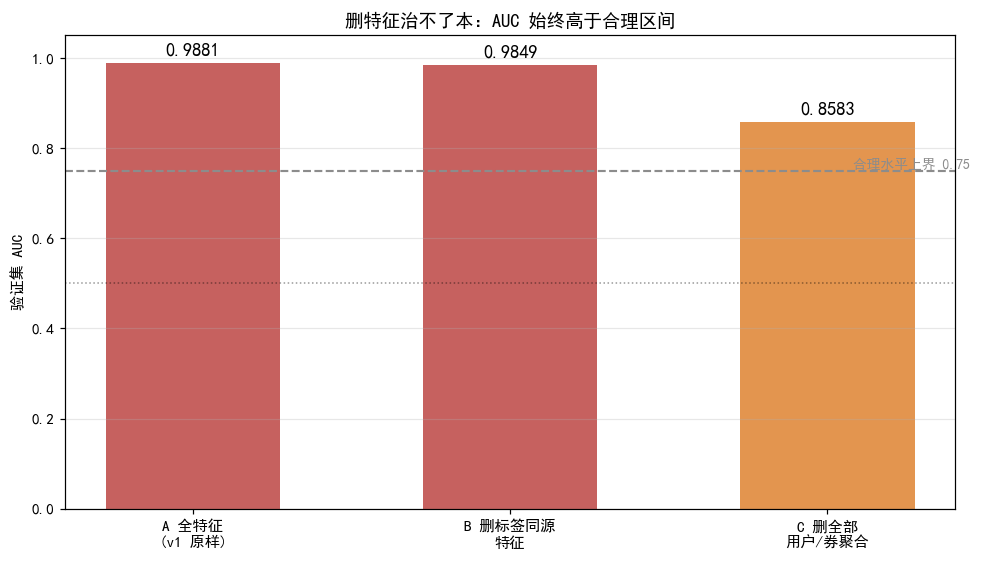

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.2))
labels = ['A 全特征\n(v1 原样)', 'B 删标签同源\n特征', 'C 删全部\n用户/券聚合']
vals = [exp_results['A'][0], exp_results['B'][0], exp_results['C'][0]]
colors = [C_WARN, C_WARN, C_ALT]
bars = ax.bar(labels, vals, color=colors, alpha=0.9, width=0.55)
for b, v in zip(bars, vals):
    ax.annotate(f'{v:.4f}', xy=(b.get_x() + b.get_width() / 2, v), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=12, fontweight='bold')
ax.axhline(0.75, color=C_GREY, ls='--', lw=1.4)
ax.text(2.45, 0.755, '合理水平上界 0.75', color=C_GREY, fontsize=9, ha='right')
ax.axhline(0.5, color='k', ls=':', lw=1, alpha=0.4)
ax.set_ylabel('验证集 AUC')
ax.set_ylim(0, 1.05)
ax.set_title('删特征治不了本：AUC 始终高于合理区间', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / '06_leakage_ablation.png', dpi=140)
plt.show()

In [9]:
ablation = pd.DataFrame([
    {'实验': 'A 全特征 + 随机切分（v1 原样）', 'AUC': round(exp_results['A'][0], 4),
     '结论': '三类泄漏叠加，严重虚高'},
    {'实验': 'B 只删 mean_interval 特征', 'AUC': round(exp_results['B'][0], 4),
     '结论': '几乎不掉 -> 泄漏冗余分布，删特征无效'},
    {'实验': 'C 删全部用户/券聚合特征', 'AUC': round(exp_results['C'][0], 4),
     '结论': '仍偏高 -> 自指泄漏未除（聚合仍覆盖全量）'},
])
ablation.to_csv(TAB_DIR / '06_leakage_ablation.csv', index=False, encoding='utf-8-sig')
print(ablation.to_string(index=False))

                          实验    AUC                                     结论
A 全特征 + 随机切分（v1 原样） 0.9881                   三类泄漏叠加，严重虚高
     B 只删 mean_interval 特征 0.9849     几乎不掉 -> 泄漏冗余分布，删特征无效
       C 删全部用户/券聚合特征 0.8583 仍偏高 -> 自指泄漏未除（聚合仍覆盖全量）


## 7. 诊断清单（可复用的排查方法）

任何高指标，**先怀疑泄漏，再庆祝**。按下面三条逐项检查：

In [10]:
checklist = pd.DataFrame([
    {'检查项': '特征是否可由标签条件重算出来？',
     '怎么查': '看特征定义式里有没有出现标签用的那个量',
     '本项目命中': '命中 —— user_mean_interval 与 gap 同源'},
    {'检查项': '聚合是否混入了验证/测试段数据？',
     '怎么查': '看 groupby 的输入是全量还是只有训练段',
     '本项目命中': '命中 —— 全量 groupby，含自身行与未来'},
    {'检查项': '切分是否尊重时间顺序？',
     '怎么查': '看用的是 train_test_split 还是按时间切',
     '本项目命中': '命中 —— 随机切分，同一主体跨集'},
])
checklist.to_csv(TAB_DIR / '06_leakage_checklist.csv', index=False, encoding='utf-8-sig')
print(checklist.to_string(index=False))

                         检查项                                 怎么查                             本项目命中
 特征是否可由标签条件重算出来？ 看特征定义式里有没有出现标签用的那个量 命中 —— user_mean_interval 与 gap 同源
聚合是否混入了验证/测试段数据？  看 groupby 的输入是全量还是只有训练段   命中 —— 全量 groupby，含自身行与未来
         切分是否尊重时间顺序？ 看用的是 train_test_split 还是按时间切         命中 —— 随机切分，同一主体跨集


## 本节小结

| 结论 | 内容 |
|---|---|
| **现象** | v1 AUC 远超该任务合理区间（0.60~0.75），高得反常 |
| **线索** | 特征排名 Top1 是「标签的另一种写法」，相关系数绝对值很高 |
| **实验** | 删特征几乎不掉分 → 泄漏是机制性的，**不是某个特征写错了** |
| **定性** | 三类叠加：目标泄漏 + 自指泄漏 + 重叠泄漏 |
| **根因** | 特征的计算范围越界：聚合覆盖全量、切分不尊重时间 |

下一步 → **07 解决数据泄漏**：改聚合的**数据范围**、改切分的**方式**。